In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("Loan_Modelling.csv")
df.head()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [7]:
df.describe()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93169.257000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,1759.455086,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,90005.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


## Experience cannot be negative

In [9]:
missing = df.isnull().sum()
missing_percent = ((missing/len(df))*100).round(1)

pd.DataFrame({"missing": missing, "Percentage": missing_percent}).query("missing > 0").sort_values("missing", ascending=False) 

,missing,Percentage


## no missing values

In [10]:
print("duplicates found: ",df.duplicated().sum())

duplicates found:  0


## Detecting outliers using boxplot

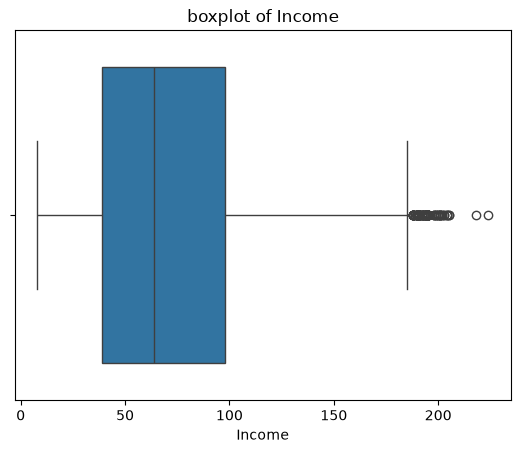

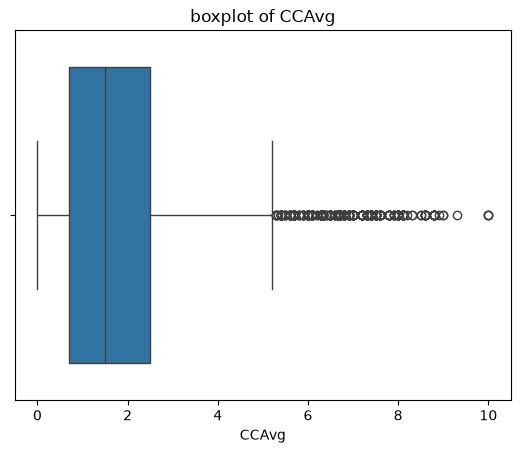

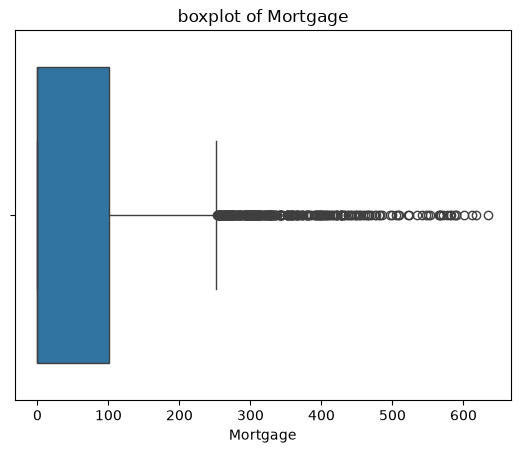

In [16]:
# Age, Experience, Income, CCAvg, Mortgage

for c in ["Income", "CCAvg", "Mortgage"]:
    sns.boxplot(x=df[c])
    plt.title(f"boxplot of {c}")
    plt.show()

## Detecting outliers using IQR

In [17]:
def iqr_bounds(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5*iqr, q3 + 1.5*iqr

low, high = iqr_bounds(df["Income"])
low1, high1 = iqr_bounds(df["CCAvg"])
low2, high2 = iqr_bounds(df["Mortgage"])


print(f"Income outlier bounds: {low:,.0f} to {high:,.0f}")
print("Income outliers:", ((df["Income"] < low) | (df["Income"] > high)).sum())

print(f"CCAvg outlier bounds: {low1:,.0f} to {high1:,.0f}")
print("CCAvg outliers:", ((df["Income"] < low) | (df["Income"] > high)).sum())

print(f"Mortgage outlier bounds: {low2:,.0f} to {high2:,.0f}")
print("Mortgage outliers:", ((df["Income"] < low) | (df["Income"] > high)).sum())


Income outlier bounds: -50 to 186
Income outliers: 96
CCAvg outlier bounds: -2 to 5
CCAvg outliers: 96
Mortgage outlier bounds: -152 to 252
Mortgage outliers: 96


## Detecting outliers using z score

In [ ]:
z = (df["Income"] - df["Income"].mean() )/ df["Income"].std()

print(" Income values for |z| > 3:\n ", df.loc[z.abs() > 3, "Income"].to_string())

z = (df["CCAvg"] - df["CCAvg"].mean() )/ df["CCAvg"].std()

print(" CCAvg values for |z| > 3:\n ", df.loc[z.abs() > 3, "CCAvg"].to_string())

z = (df["Mortgage"] - df["Mortgage"].mean() )/ df["Mortgage"].std()

print(" Mortgage values for |z| > 3:\n ", df.loc[z.abs() > 3, "Mortgage"].to_string())

 Income values for |z| > 3:
  3896    224
4993    218
 Mortgage values for |z| > 3:
  42      412
59      455
119     366
288     391
303     617
327     402
338     392
354     419
365     466
459     458
473     547
479     470
528     378
570     485
679     364
684     449
782     587
888     372
952     524
1023    366
1111    442
1162    394
1167    475
1273    437
1277    428
1288    366
1303    382
1304    397
1328    380
1359    433
1372    483
1623    455
1674    421
1716    565
1736    394
1783    601
1789    567
1875    389
1889    372
1937    589
1970    397
2027    380
2041    535
2076    398
2217    446
2319    422
2382    428
2394    505
2422    400
2443    422
2541    569
2590    374
2653    408
2668    406
2687    452
2714    432
2753    477
2768    396
2769    582
2776    380
2812    467
2841    565
2934    635
2942    385
2946    437
2956    522
2989    496
3012    415
3020    392
3021    461
3065    368
3209    373
3304    383
3357    408
3373    442
3411    427
34

In [22]:
df_clean = df.copy()

## Treating outliers

In [23]:
for x in ["Income", "Mortgage"]:
    df_clean[x] = df_clean[x].clip(lower = low, upper = high)
    print(f"{x} max after capping:", df_clean[x].max())

Income max after capping: 186.5
Mortgage max after capping: 186.5


In [24]:
df_clean.head()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49.0,91107,4,1.6,1,0.0,0,1,0,0,0
1,2,45,19,34.0,90089,3,1.5,1,0.0,0,1,0,0,0
2,3,39,15,11.0,94720,1,1.0,1,0.0,0,0,0,0,0
3,4,35,9,100.0,94112,1,2.7,2,0.0,0,0,0,0,0
4,5,35,8,45.0,91330,4,1.0,2,0.0,0,0,0,0,1


## log transform of skewed data

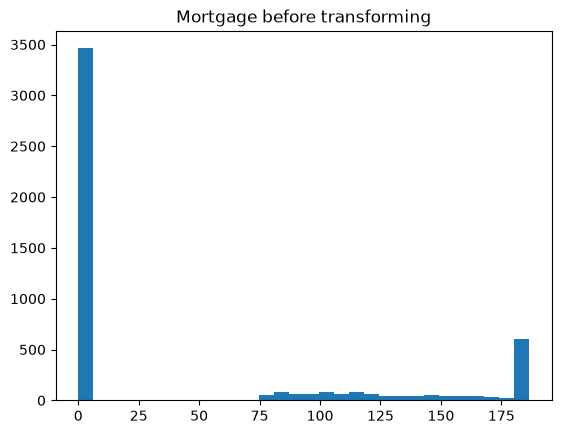

In [29]:
#before transformation
plt.hist(df_clean["Mortgage"], bins=30)
plt.title("Mortgage before transforming")
plt.show()

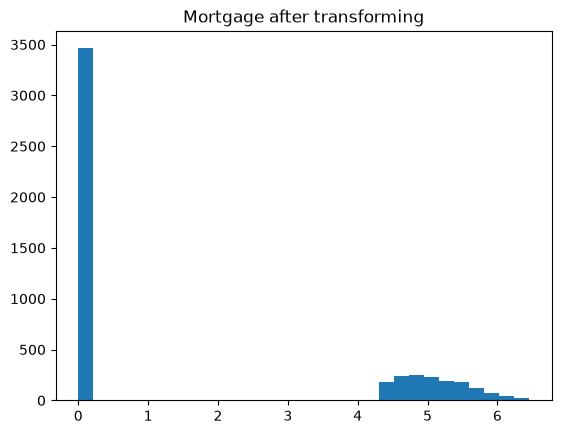

In [31]:
#after transforming
plt.hist(np.log1p(df["Mortgage"].dropna()), bins=30)
plt.title("Mortgage after transforming")
plt.show()

## Feature scaling

In [32]:
from sklearn.preprocessing import MinMaxScaler

num_columns = ["Age", "Experience", "Income", "Mortgage"]

minmax = MinMaxScaler().fit_transform(df_clean[num_columns])

print("\nMinMaxScaler -> values in [0, 1]:")
print(pd.DataFrame(minmax, columns=num_columns).describe().loc[["min", "max"]].round(2))


MinMaxScaler -> values in [0, 1]:
     Age  Experience  Income  Mortgage
min  0.0         0.0     0.0       0.0
max  1.0         1.0     1.0       1.0


## Train test split

In [37]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=["CCAvg", "ID"])
y = df_clean["CCAvg"]

x_train2, x_test2, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)
print("Train:", x_train2.shape, " Test:", x_test2.shape)

Train: (3500, 12)  Test: (1500, 12)


## Training regression model

In [39]:
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lin_reg_model1 = LinearRegression()
lin_reg_model1.fit(x_train2, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](12,)","[ 0.06,-0.07, 0.02,..., 0.13,-0.05,-0.01]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](12,)","['Age','Experience','Income',...,'CD_Account','Online','CreditCard']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.087
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,12
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(12)


## Evaluating model

In [40]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))

# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
        },
        index=[0],
    )

    return df_perf

In [41]:
# Checking model performance on train set
print("Training Performance:")
lin_reg_model1_perf_train = model_performance_regression(
    lin_reg_model1, x_train2, y_train
)
lin_reg_model1_perf_train

Training Performance:


,RMSE,MAE,R-squared,Adj. R-squared
0,1.311486,0.952501,0.428259,0.426291


In [42]:
# Checking model performance on test set
print("Test Performance:")
lin_reg_model1_perf_test = model_performance_regression(lin_reg_model1, x_test2, y_test)
lin_reg_model1_perf_test

Test Performance:


,RMSE,MAE,R-squared,Adj. R-squared
0,1.370117,0.981526,0.405835,0.40104


In [43]:
X = df.drop(columns=["CCAvg", "ID"])
y = df["CCAvg"]

x_train1, x_test1, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)
print("Train:", x_train1.shape, " Test:", x_test1.shape)

Train: (3500, 12)  Test: (1500, 12)


In [44]:
lin_reg_model2 = LinearRegression()
lin_reg_model2.fit(x_train1, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](12,)","[ 0.06,-0.07, 0.02,..., 0.14,-0.05,-0.01]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](12,)","['Age','Experience','Income',...,'CD_Account','Online','CreditCard']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.078
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,12
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(12)


In [45]:
# Checking model performance on train set
print("Training Performance:")
lin_reg_model2_perf_train = model_performance_regression(
    lin_reg_model2, x_train1, y_train
)
lin_reg_model2_perf_train

Training Performance:


,RMSE,MAE,R-squared,Adj. R-squared
0,1.308245,0.950743,0.431081,0.429123


In [46]:
# Checking model performance on test set
print("Test Performance:")
lin_reg_model2_perf_test = model_performance_regression(lin_reg_model2, x_test1, y_test)
lin_reg_model2_perf_test

Test Performance:


,RMSE,MAE,R-squared,Adj. R-squared
0,1.36896,0.980326,0.406838,0.402052
